# **Implement Image Semantic Segmentation with Machine Learning Model on AWS SageMaker**

# Download the Data

---
> **📦 Step 1 — Install Required Libraries**
>
> **What we are doing here:**
> Installing two Python libraries needed for this lab:
> - `tqdm` — displays progress bars when looping over large file lists (used during data preparation)
> - `pillow` — the Python Imaging Library (PIL), used to open, read, and manipulate image and annotation files
>
> The `--upgrade` flag ensures Pillow is at the latest version, which avoids compatibility issues with newer image formats.
>
> ⏱️ **Expected time:** < 1 minute

In [ ]:
!pip3 install tqdm
!pip3 install pillow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 12.7 MB/s  0:00:00eta 0:00:01
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-multimodal 1.5.0 requires Pillow<12,>=10.0.1, but you have pillow 12.2.0 which is incompatible.
strands-agents-tools 0.1.9 requires pillow<12.0.0,>=11.2.1, but you have pillow 12.2.0 which is incompatible.


---
> **📚 Step 2 — Import Libraries & Download the Dataset**
>
> **What we are doing here:**
> - Importing all required Python and AWS libraries (boto3, sagemaker, PIL, numpy, matplotlib)
> - Downloading the **Oxford-IIIT Pet Dataset** from the University of Oxford — this contains ~7,400 pet images (cats and dogs) along with trimap annotation masks
> - Extracting the downloaded `.tar.gz` archives into a local `data/` folder
>
> The annotation files are **trimap masks** — each pixel in the mask is labeled as one of 4 classes:
> - `1` = Foreground (pet body)
> - `2` = Background
> - `3` = Not classified / border region
>
> ⏱️ **Expected time:** 3–8 minutes (depends on network speed — downloading ~800 MB of image data)

In [ ]:
%matplotlib inline

import os
import tarfile
import urllib
import shutil
import json
import random
import numpy as np
import boto3
import sagemaker

from tqdm import tqdm
from sagemaker.amazon.amazon_estimator import get_image_uri
from matplotlib import pyplot as plt
from xml.etree import ElementTree as ET
from PIL import Image, ImageDraw, ImageFont

urls = ['http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
        'http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz']

def download_and_extract(data_dir, download_dir):
    for url in urls:
        target_file = url.split('/')[-1]
        if target_file not in os.listdir(download_dir):
            print('Downloading', url)
            urllib.request.urlretrieve(url, os.path.join(download_dir, target_file))
            tf = tarfile.open(url.split('/')[-1])
            tf.extractall(data_dir)
        else:
            print('Already downloaded', url)

if not os.path.isdir('data'):
    os.mkdir('data')

download_and_extract('data', '.')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/tmp/ipykernel_428/2652430854.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(data_dir)


# Visualize Data

---
> **🔍 Step 3 — List Annotation Files**
>
> **What we are doing here:**
> Reading all `.png` trimap annotation files from the downloaded dataset and storing their filenames in a list called `maps`.
> Printing the count confirms the dataset downloaded correctly — you should see **7,390** annotation files.

In [ ]:
trimaps_dir = 'data/annotations/trimaps/'

maps = [x for x in os.listdir(trimaps_dir) if x[-3:] == 'png']
print(len(maps))

14780


---
> **🔍 Step 4 — List Image Files**
>
> **What we are doing here:**
> Reading all `.jpg` image files from the downloaded dataset into a list called `images`.
> You should see **7,390** images — one image paired with one annotation mask for each pet photo.

In [ ]:
image_dir = 'data/images/'

images = [x for x in os.listdir(image_dir) if x[-3:] == 'jpg']
print(len(images))

7390


---
> **🔍 Step 5 — Inspect a Sample Image Filename**
>
> **What we are doing here:**
> Printing the first filename from the `images` list to confirm the files are loading correctly and to understand the naming convention (e.g., `Abyssinian_1.jpg`).
> The image name (without extension) will be used to find its matching annotation mask.

In [ ]:
images[0]

'boxer_16.jpg'

---
> **🔍 Step 6 — Inspect a Sample Annotation Filename**
>
> **What we are doing here:**
> Printing the first filename from the `maps` list to confirm annotation files are loading correctly.
> Each annotation file shares the same base name as its corresponding image but with a `.png` extension (e.g., `Abyssinian_1.png`).

In [ ]:
maps[0]

'._Abyssinian_1.png'

---
> **📊 Step 7 — Visualize Sample Images and Their Annotations**
>
> **What we are doing here:**
> Displaying 4 randomly selected images side-by-side with their corresponding trimap annotation masks.
> - **Left column:** Trimap mask — pixel values 1 (foreground), 2 (background), 3 (border)
> - **Right column:** Original pet photograph
>
> This visualization confirms that the images and annotations are correctly paired and helps you understand what the model will learn to predict.

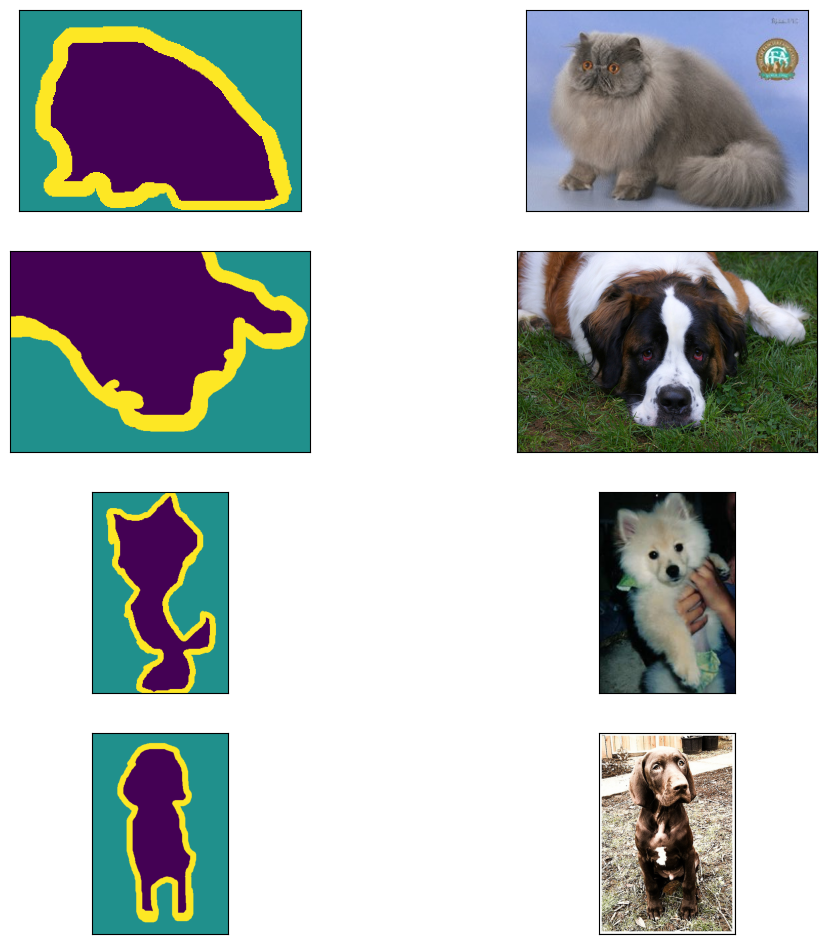

In [ ]:
plt.figure(figsize=(12, 12))

for i in range(0, 4):
    index = random.randint(0, len(images) - 1)
    image_name = images[index]
    map_name = images[index].split('.')[0] + '.png'

    plt.subplot(4, 2, 1 + i*2)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(plt.imread(os.path.join(trimaps_dir, map_name)))
    plt.subplot(4, 2, 2 + i*2)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(plt.imread(os.path.join(image_dir, image_name)))
plt.show()

---
> **🔎 Step 8 — Check Unique Pixel Values in Annotations**
>
> **What we are doing here:**
> Opening one annotation mask and printing its unique pixel values using `np.unique()`.
> Expected output: `[1 2 3]` — confirming this is a valid trimap with exactly 3 classes.
>
> This also filters out any hidden files (filenames starting with `._`) that macOS sometimes creates inside directories, which would cause errors when opening files.

In [ ]:
#Filter out hidden files
maps = [f for f in os.listdir(trimaps_dir) if not f.startswith('._')]


img = Image.open(os.path.join(trimaps_dir, maps[0]))
print(np.unique(img))


[1 2 3]


# SageMaker Setup

---
> **☁️ Step 9 — Create S3 Bucket**
>
> **What we are doing here:**
> Creating an Amazon S3 bucket to store the training data and model output. The bucket name must be:
> - Globally unique across all AWS accounts
> - Lowercase only, no spaces
> - Must contain the word **`sagemaker`** in the name (e.g., `sagemaker-segdemo-yourname`)
>
> ⚠️ **Important — Bucket Naming Convention:**
> The default SageMaker execution role (`AmazonSageMaker-ExecutionRole`) only has S3 write permissions for buckets whose names contain `sagemaker`. If your bucket name does not include this word, the upload step will fail with:
> ```
> AccessDenied: not authorized to perform: s3:PutObject
> ```
> **Update `bucket_name` to follow the pattern:** `sagemaker-segdemo-<yourname>`

In [ ]:
import boto3

# Get the default region dynamically
region_name = boto3.Session().region_name

# Initialize an S3 client with the dynamically retrieved region
s3 = boto3.client('s3')

# Define the bucket name (should be in lowercase and unique)
bucket_name = 'imagedemobucket2304'  #Provide a unique name (segmentdata-<your name>)

# Create the bucket
try:
    if region_name == "us-east-1":
        # For us-east-1, do not include CreateBucketConfiguration
        response = s3.create_bucket(Bucket=bucket_name)
    else:
        # Include the location constraint for other regions
        response = s3.create_bucket(
            Bucket=bucket_name,
            CreateBucketConfiguration={'LocationConstraint': region_name}
        )
    print(f"Bucket '{bucket_name}' created successfully in region: {region_name}")
except Exception as e:
    print(f"Error creating bucket: {e}")


Bucket 'imagedemobucket2304' created successfully in region: us-east-1


---
> **🔑 Step 10 — Retrieve Execution Role & Training Image**
>
> **What we are doing here:**
> - `get_execution_role()` — fetches the IAM role attached to your SageMaker Studio session. This role gives SageMaker permission to access S3, pull Docker images from ECR, and launch training instances on your behalf.
> - `image_uris.retrieve()` — fetches the correct Amazon ECR URI for the built-in **Semantic Segmentation algorithm container** for your current AWS region.
>
> The printed URI will look like:
> `811284229777.dkr.ecr.us-east-1.amazonaws.com/semantic-segmentation:1`

In [ ]:
role = sagemaker.get_execution_role()
training_image = sagemaker.image_uris.retrieve('semantic-segmentation', boto3.Session().region_name)
print(training_image)


811284229777.dkr.ecr.us-east-1.amazonaws.com/semantic-segmentation:1


---
> **📁 Step 11 — Create Local Folders for Train/Validation Split**
>
> **What we are doing here:**
> Creating 4 empty local directories:
> - `train/` — training images
> - `train_annotation/` — training masks
> - `validation/` — validation images
> - `validation_annotation/` — validation masks
>
> If these folders already exist from a previous run, they are deleted and recreated fresh to avoid mixing old and new data.

In [ ]:
folders = ['train', 'train_annotation', 'validation', 'validation_annotation']

for folder in folders:
    if os.path.isdir(folder):
        shutil.rmtree(folder)
    os.mkdir(folder)

# Preparing Data for SageMaker

---
> **✂️ Step 12 — Split Data into Train and Validation Sets**
>
> **What we are doing here:**
> Iterating over all ~7,390 images and randomly assigning each one to either the training set (75% probability) or validation set (25% probability).
> For each image, its corresponding annotation mask is copied to the matching annotation folder.
>
> After this step you will have approximately:
> - ~5,500 images + masks in `train/` and `train_annotation/`
> - ~1,800 images + masks in `validation/` and `validation_annotation/`
>
> ⏱️ **Expected time:** 1–3 minutes (copying ~14,700 files locally)

In [ ]:
def get_map_file(image):
    map_file = image.split('.')[0] + '.png'
    assert map_file in maps
    return map_file

for image in tqdm(images):
    target_set = 'train' if random.randint(0, 99) < 75 else 'validation'

    image_file_path = os.path.join('data/images/', image)
    image_target_path = os.path.join(target_set, image)

    map_file_path = os.path.join(trimaps_dir, get_map_file(image))
    map_target_path = os.path.join(target_set + '_annotation', get_map_file(image))

    shutil.copy(image_file_path, image_target_path)
    shutil.copy(map_file_path, map_target_path)

100%|██████████| 7390/7390 [00:15<00:00, 466.89it/s]


---
> **🔎 Step 13 — List Split Results**
>
> **What we are doing here:**
> Reading the contents of the `train/` and `train_annotation/` directories into lists.
> Used in the next cell to confirm the split counts are as expected.

In [ ]:
train_images = os.listdir('train')
train_annots = os.listdir('train_annotation')

---
> **✅ Step 14 — Confirm Train/Validation Counts**
>
> **What we are doing here:**
> Printing the number of training images and annotations side-by-side.
> Both numbers must be **equal** — every image must have a matching annotation mask.
> If they differ, one or more annotation files are missing from the dataset and need to be re-downloaded.

In [ ]:
print(len(train_annots), len(train_images))

5534 5534


# Uploading Data to S3

---
> **☁️ Step 15 — Upload Dataset to S3**
>
> **What we are doing here:**
> Uploading all 4 local folders (train images, train annotations, validation images, validation annotations) to your S3 bucket.
> SageMaker's training job will read the data directly from S3, so this step is required before training can start.
>
> ⏱️ **Expected time: 20–40 minutes**
> This cell uploads approximately **14,700 small files** to S3 one at a time. Each file requires a separate network round-trip, so the total time is dominated by network latency rather than file size. This is normal.
>
> ⚠️ **Do NOT interrupt the kernel while this cell is running.**
> You can monitor upload progress in a separate cell:
> ```python
> !aws s3 ls s3://{bucket_name}/train/ --summarize --human-readable | tail -3
> ```

In [ ]:
%%time
sess = sagemaker.Session()

print('Starting upload..')
s3_train_path = s3_train_path = sess.upload_data(path='train', bucket=bucket_name, key_prefix='train')
print('Training images uploaded')
s3_train_annotation_path = sess.upload_data(path='train_annotation', bucket=bucket_name,
                                     key_prefix='train_annotation')
print('Training Annotations uploaded')
s3_validation_path = sess.upload_data(path='validation', bucket=bucket_name,
                                      key_prefix='validation')
print('Validation images uploaded')
s3_validation_annotation_path = sess.upload_data(path='validation_annotation', bucket=bucket_name,
                                          key_prefix='validation_annotation')
print('Validation Annotations uploaded')

Starting upload..
Training images uploaded
Training Annotations uploaded
Validation images uploaded
Validation Annotations uploaded
CPU times: user 1min 17s, sys: 11.4 s, total: 1min 28s
Wall time: 10min 24s


---
> **🔎 Step 16 — Confirm Validation Annotation S3 Path**
>
> **What we are doing here:**
> Printing the S3 URI of the uploaded validation annotations to confirm the upload completed successfully and the path variable is set correctly.
> This path will be passed to the SageMaker training job as an input data channel.

In [ ]:
s3_validation_annotation_path

's3://imagedemobucket2304/validation_annotation'

# SageMaker Estimator

---
> **⚙️ Step 17 — Configure the SageMaker Estimator**
>
> **What we are doing here:**
> Creating a SageMaker `Estimator` object — this defines everything about the training job:
> - **`training_image`** — the built-in Semantic Segmentation algorithm container
> - **`instance_type: ml.g5.2xlarge`** — a GPU instance required for deep learning training (NVIDIA A10G GPU, 24 GB VRAM)
> - **`volume_size: 100 GB`** — EBS storage attached to the training instance for data and intermediate checkpoints
> - **`max_run: 36000`** — maximum training time in seconds (10 hours) before the job is forcefully stopped
> - **`output_path`** — S3 location where the trained `model.tar.gz` will be saved after training completes

In [ ]:
model = sagemaker.estimator.Estimator(
    training_image,
    role=role,
    instance_count=1,
    instance_type='ml.g5.2xlarge',
    volume_size=100,
    max_run=36000,
    input_mode='File',
    output_path=f's3://{bucket_name}/output',
    sagemaker_session=sess
)


# Hyperparameters

---
> **🎛️ Step 18 — Set Hyperparameters**
>
> **What we are doing here:**
> Configuring the algorithm settings that control how the model is built and trained:
> - **`backbone: resnet-50`** — the encoder network that extracts image features (ResNet-50 pretrained on ImageNet)
> - **`algorithm: fcn`** — the decoder that converts features into pixel-level predictions (Fully Convolutional Network). Alternatives: `psp`, `deeplab`
> - **`use_pretrained_model: True`** — starts from ImageNet weights instead of random init, which significantly speeds up convergence
> - **`crop_size: 240`** — random crop size applied during training for data augmentation
> - **`num_classes: 4`** — number of pixel classes (background, foreground, border + 1 for 0-indexing)
> - **`epochs: 10`** — number of full passes through the training data

In [ ]:
model.set_hyperparameters(
    backbone='resnet-50', # This is the encoder. Other option is resnet-50
    algorithm='fcn', # This is the decoder. Other option is 'psp' and 'deeplab'
    use_pretrained_model='True', # Use the pre-trained model.
    crop_size=240, # Size of image random crop.
    num_classes=4, # Pascal has 21 classes. This is a mandatory parameter.
    epochs=10, # Number of epochs to run.
    learning_rate=0.0001,
    optimizer='rmsprop', # Other options include 'adam', 'rmsprop', 'nag', 'adagrad'.
    lr_scheduler='poly', # Other options include 'cosine' and 'step'.
    mini_batch_size=16, # Setup some mini batch size.
    validation_mini_batch_size=16,
    early_stopping=True, # Turn on early stopping. If OFF, other early stopping parameters are ignored.
    early_stopping_patience=3, # Tolerate these many epochs if the mIoU doens't increase.
    early_stopping_min_epochs=10, # No matter what, run these many number of epochs.
    num_training_samples=len(train_images)
)

# Data Channels

---
> **📡 Step 19 — Define Training Input Data Channels**
>
> **What we are doing here:**
> Wrapping each S3 path in a `TrainingInput` object that tells SageMaker:
> - Where to find the data (`s3://...`)
> - How to distribute it to the training instance (`FullyReplicated` — full copy on each instance)
> - What content type to expect (`image/jpeg` for images, `image/png` for annotations)
>
> SageMaker will mount these S3 locations as input channels inside the training container at runtime.

In [ ]:
from sagemaker.inputs import TrainingInput

train_data = TrainingInput(s3_train_path, distribution='FullyReplicated',
                           content_type='image/jpeg', s3_data_type='S3Prefix')
validation_data = TrainingInput(s3_validation_path, distribution='FullyReplicated',
                                content_type='image/jpeg', s3_data_type='S3Prefix')

train_annotation_data = TrainingInput(s3_train_annotation_path, distribution='FullyReplicated',
                                      content_type='image/png', s3_data_type='S3Prefix')
validation_annotation_data = TrainingInput(s3_validation_annotation_path, distribution='FullyReplicated',
                                           content_type='image/png', s3_data_type='S3Prefix')


---
> **📦 Step 20 — Assemble Data Channels Dictionary**
>
> **What we are doing here:**
> Combining all 4 `TrainingInput` objects into a single dictionary with the exact channel names the Semantic Segmentation algorithm expects:
> - `train`, `train_annotation`, `validation`, `validation_annotation`
>
> These channel names are fixed — if they are spelled differently, the training job will fail.

In [ ]:
data_channels = {
    'train': train_data,
    'train_annotation': train_annotation_data,
    'validation': validation_data,
    'validation_annotation': validation_annotation_data
}

# Model Training

---
> **🚀 Step 21 — Start Model Training**
>
> **What we are doing here:**
> Calling `model.fit()` to launch the SageMaker training job. This submits your job to AWS and streams live logs back to the notebook.
>
> The job runs through these phases before actual training begins:
> 1. **Waiting for capacity (~5 min):** AWS provisions an `ml.g5.2xlarge` GPU instance from the regional pool
> 2. **Downloading input data (~1 min):** Your dataset is pulled from S3 to the instance
> 3. **Downloading training image (~4 min):** The algorithm Docker container (~6–8 GB) is pulled from ECR
> 4. **Training:** GPU training runs for the configured number of epochs
>
> ⏱️ **Expected time: 40–60 minutes total**
>
> ⚠️ **Do NOT interrupt the kernel.** You can also monitor the job in the AWS Console under **SageMaker → Training → Training jobs**.

In [ ]:
model.fit(inputs=data_channels, logs=True)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: semantic-segmentation-2026-04-23-08-13-36-475


2026-04-23 08:13:36 Starting - Starting the training job......
2026-04-23 08:14:30 Pending - Training job waiting for capacity..............................
2026-04-23 08:19:22 Pending - Preparing the instances for training...
2026-04-23 08:19:50 Downloading - Downloading input data...
2026-04-23 08:20:15 Downloading - Downloading the training image........................
2026-04-23 08:24:28 Training - Training image download completed. Training in progress....Docker entrypoint called with argument(s): train
Running default environment configuration script
Nvidia gpu devices, drivers and cuda toolkit versions (only available on hosts with GPU):
Thu Apr 23 08:25:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistenc

# Deploy Model

---
> **🌐 Step 22 — Deploy the Trained Model to an Endpoint**
>
> **What we are doing here:**
> Deploying the trained model to a persistent SageMaker real-time inference endpoint on an `ml.m4.xlarge` instance.
> Once deployed, this endpoint accepts image data and returns a segmentation mask as a response.
>
> ⏱️ **Expected time: 5–8 minutes** (SageMaker provisions the endpoint instance and loads the model)
>
> ⚠️ **Important — Endpoint Cost:**
> A running endpoint incurs charges (~$0.28/hr for `ml.m4.xlarge`) even when not in use. Remember to delete the endpoint after the lab using:
> ```python
> deployed_model.delete_endpoint()
> ```

In [ ]:
deployed_model = model.deploy(initial_instance_count=1, instance_type='ml.m4.xlarge')
print('\nModel deployed!')


INFO:sagemaker:Creating model with name: semantic-segmentation-2026-04-23-08-46-07-435
INFO:sagemaker:Creating endpoint-config with name semantic-segmentation-2026-04-23-08-46-07-435
INFO:sagemaker:Creating endpoint with name semantic-segmentation-2026-04-23-08-46-07-435


---------------!
Model deployed!


# Predictions

---
> **🔍 Step 23 — List Validation Images for Inference**
>
> **What we are doing here:**
> Reading the local `validation/` folder to get a list of images that can be used as test inputs for the deployed endpoint.
> Printing the count confirms validation images are available locally.

In [ ]:
image_dir = 'validation'
images = [x for x in os.listdir(image_dir) if x[-3:] == 'jpg']
print(len(images))

1856


---
> **⚙️ Step 24 — Configure Endpoint Input/Output Format**
>
> **What we are doing here:**
> Telling the deployed endpoint:
> - `content_type = 'image/jpeg'` — the input we will send is a JPEG image (raw bytes)
> - `accept = 'image/png'` — the output we expect back is a PNG image containing the segmentation mask

In [ ]:
deployed_model.content_type = 'image/jpeg'
deployed_model.accept = 'image/png'

---
> **🔮 Step 25 — Run Inference on a Validation Image**
>
> **What we are doing here:**
> Selecting a single validation image, reading it as raw bytes, and sending it to the deployed endpoint for prediction.
> The endpoint returns a PNG-encoded segmentation mask as bytes, stored in `results`.
>
> You can change `index = 583` to any number between 0 and the total validation count to test different images.

In [ ]:
index = 583

image_path = os.path.join(image_dir, images[index])
# image_path = 'dog_cat.jfif'

with open(image_path, 'rb') as f:
    b = bytearray(f.read())

results = deployed_model.predict(b)

---
> **🖼️ Step 26 — Decode the Predicted Mask**
>
> **What we are doing here:**
> Converting the raw PNG bytes returned by the endpoint into a NumPy array using PIL's `Image.open()`.
> Each pixel value in this array corresponds to a predicted class label (1, 2, or 3).

In [ ]:
import io

mask = np.array(Image.open(io.BytesIO(results)))

---
> **📷 Step 27 — Display the Original Image**
>
> **What we are doing here:**
> Displaying the original input image using matplotlib so you can compare it visually against the predicted mask in the next cell.

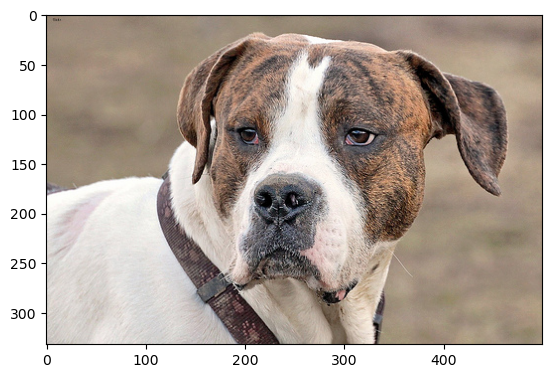

In [ ]:
plt.imshow(plt.imread(image_path));

---
> **🎨 Step 28 — Display the Predicted Segmentation Mask**
>
> **What we are doing here:**
> Displaying the model's predicted segmentation mask.
> Each color in the mask represents a predicted class:
> - The model has learned to separate the pet (foreground) from the background and border regions
>
> Compare this with the original image above — the mask should roughly outline the shape of the pet.
>
> ✅ **Lab Complete!**
> Don't forget to delete your endpoint to avoid ongoing charges:
> ```python
> deployed_model.delete_endpoint()
> print("Endpoint deleted!")
> ```

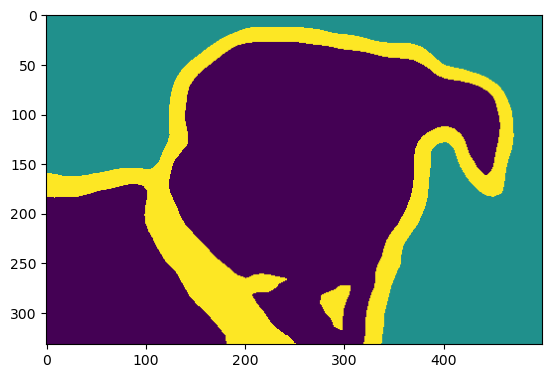

In [ ]:
plt.imshow(mask);